In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from textblob import TextBlob
from collections import Counter
import nltk

In [7]:
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\karan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\karan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
df = pd.read_csv(
    r"C:\Users\karan\OneDrive\Desktop\customer_reviews.csv"
)

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

Dataset Loaded Successfully!
Shape: (3799, 2)


In [9]:
df.head()

,Unnamed: 0,reviews
0,0,✅ Trip Verified | A premium price for a sub-p...
1,1,✅ Trip Verified | Really terrible user experi...
2,2,✅ Trip Verified | Very impressed with BA. Chec...
3,3,"✅ Trip Verified | LHR - SFO, LAS - LGW August..."
4,4,Not Verified | I flew from Malaga via LHR to...


In [10]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Unnamed: 0', 'reviews']


In [11]:
print("\nDataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)


Dataset Shape:
(3799, 2)

Data Types:
Unnamed: 0     int64
reviews       object
dtype: object


In [12]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Unnamed: 0    0
reviews       0
dtype: int64


In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [14]:
possible_columns = [
    "Review",
    "review",
    "Reviews",
    "reviews",
    "Review Text",
    "review_text",
    "Text",
    "text",
    "Comment",
    "comment",
    "Feedback",
    "feedback"
]

review_column = None

for column in possible_columns:
    if column in df.columns:
        review_column = column
        break

print("Detected Review Column:", review_column)

Detected Review Column: reviews


In [15]:
if review_column is None:
    raise ValueError(
        "Review column was not detected. Check df.columns.tolist()"
    )

data = df[[review_column]].copy()

data = data.rename(
    columns={review_column: "Review"}
)

print(data.head())

                                              Review
0  ✅ Trip Verified |  A premium price for a sub-p...
1  ✅ Trip Verified |  Really terrible user experi...
2  ✅ Trip Verified | Very impressed with BA. Chec...
3  ✅ Trip Verified |  LHR - SFO, LAS - LGW August...
4  Not Verified |   I flew from Malaga via LHR to...


In [16]:
print("Missing Reviews:", data["Review"].isnull().sum())

Missing Reviews: 0


In [17]:
data = data.dropna(subset=["Review"])

In [18]:
data["Review"] = data["Review"].astype(str)
print(data.head())

                                              Review
0  ✅ Trip Verified |  A premium price for a sub-p...
1  ✅ Trip Verified |  Really terrible user experi...
2  ✅ Trip Verified | Very impressed with BA. Chec...
3  ✅ Trip Verified |  LHR - SFO, LAS - LGW August...
4  Not Verified |   I flew from Malaga via LHR to...


In [19]:
def clean_text(text):
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    
    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

In [20]:
data["Clean_Review"] = data["Review"].apply(clean_text)

In [21]:
data[["Review", "Clean_Review"]].head(10)

,Review,Clean_Review
0,✅ Trip Verified | A premium price for a sub-p...,trip verified a premium price for a subpar pro...
1,✅ Trip Verified | Really terrible user experi...,trip verified really terrible user experience ...
2,✅ Trip Verified | Very impressed with BA. Chec...,trip verified very impressed with ba check in ...
3,"✅ Trip Verified | LHR - SFO, LAS - LGW August...",trip verified lhr sfo las lgw august in club w...
4,Not Verified | I flew from Malaga via LHR to...,not verified i flew from malaga via lhr to bos...
5,✅ Trip Verified | Milan to Miami return via L...,trip verified milan to miami return via london...
6,✅ Trip Verified | BA created a new low-cost s...,trip verified ba created a new lowcost subsidi...
7,✅ Trip Verified | I flew with British Airway...,trip verified i flew with british airways from...
8,✅ Trip Verified | Manchester to Copenhagen vi...,trip verified manchester to copenhagen via lon...
9,✅ Trip Verified | I have never seen such disr...,trip verified i have never seen such disrespec...


In [22]:
def get_polarity(text):
    return TextBlob(text).sentiment.polarity

In [23]:
data["Polarity"] = data["Clean_Review"].apply(get_polarity)

In [24]:
data[["Clean_Review", "Polarity"]].head(10)

,Clean_Review,Polarity
0,trip verified a premium price for a subpar pro...,-0.122222
1,trip verified really terrible user experience ...,-0.050000
2,trip verified very impressed with ba check in ...,0.277114
3,trip verified lhr sfo las lgw august in club w...,0.078047
4,not verified i flew from malaga via lhr to bos...,-0.060417
5,trip verified milan to miami return via london...,-0.239410
6,trip verified ba created a new lowcost subsidi...,0.069951
7,trip verified i flew with british airways from...,0.026961
8,trip verified manchester to copenhagen via lon...,-0.083106
9,trip verified i have never seen such disrespec...,-0.175000


In [25]:
def get_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity

data["Subjectivity"] = data["Clean_Review"].apply(get_subjectivity)

In [26]:
data[[
    "Clean_Review",
    "Polarity",
    "Subjectivity"
]].head(10)

,Clean_Review,Polarity,Subjectivity
0,trip verified a premium price for a subpar pro...,-0.122222,0.564206
1,trip verified really terrible user experience ...,-0.050000,0.550000
2,trip verified very impressed with ba check in ...,0.277114,0.413958
3,trip verified lhr sfo las lgw august in club w...,0.078047,0.463620
4,not verified i flew from malaga via lhr to bos...,-0.060417,0.300000
5,trip verified milan to miami return via london...,-0.239410,0.638368
6,trip verified ba created a new lowcost subsidi...,0.069951,0.531707
7,trip verified i flew with british airways from...,0.026961,0.369118
8,trip verified manchester to copenhagen via lon...,-0.083106,0.562348
9,trip verified i have never seen such disrespec...,-0.175000,0.366667


In [27]:
def classify_sentiment(polarity):
    
    if polarity > 0:
        return "Positive"
    
    elif polarity < 0:
        return "Negative"
    
    else:
        return "Neutral"

In [28]:
data["Sentiment"] = data["Polarity"].apply(
    classify_sentiment
)

In [29]:
data.head(10)

,Review,Clean_Review,Polarity,Subjectivity,Sentiment
0,✅ Trip Verified | A premium price for a sub-p...,trip verified a premium price for a subpar pro...,-0.122222,0.564206,Negative
1,✅ Trip Verified | Really terrible user experi...,trip verified really terrible user experience ...,-0.050000,0.550000,Negative
2,✅ Trip Verified | Very impressed with BA. Chec...,trip verified very impressed with ba check in ...,0.277114,0.413958,Positive
3,"✅ Trip Verified | LHR - SFO, LAS - LGW August...",trip verified lhr sfo las lgw august in club w...,0.078047,0.463620,Positive
4,Not Verified | I flew from Malaga via LHR to...,not verified i flew from malaga via lhr to bos...,-0.060417,0.300000,Negative
5,✅ Trip Verified | Milan to Miami return via L...,trip verified milan to miami return via london...,-0.239410,0.638368,Negative
6,✅ Trip Verified | BA created a new low-cost s...,trip verified ba created a new lowcost subsidi...,0.069951,0.531707,Positive
7,✅ Trip Verified | I flew with British Airway...,trip verified i flew with british airways from...,0.026961,0.369118,Positive
8,✅ Trip Verified | Manchester to Copenhagen vi...,trip verified manchester to copenhagen via lon...,-0.083106,0.562348,Negative
9,✅ Trip Verified | I have never seen such disr...,trip verified i have never seen such disrespec...,-0.175000,0.366667,Negative


In [30]:
sentiment_counts = data["Sentiment"].value_counts()
print(sentiment_counts)

Sentiment
Positive    2644
Negative    1137
Neutral       18
Name: count, dtype: int64


In [31]:
sentiment_percentage = (
    data["Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_percentage)

Sentiment
Positive    69.60
Negative    29.93
Neutral      0.47
Name: proportion, dtype: float64


In [32]:
sentiment_summary = pd.DataFrame({
    "Count": sentiment_counts,
    "Percentage": sentiment_percentage
})

sentiment_summary

,Count,Percentage
Sentiment,,
Positive,2644,69.60
Negative,1137,29.93
Neutral,18,0.47


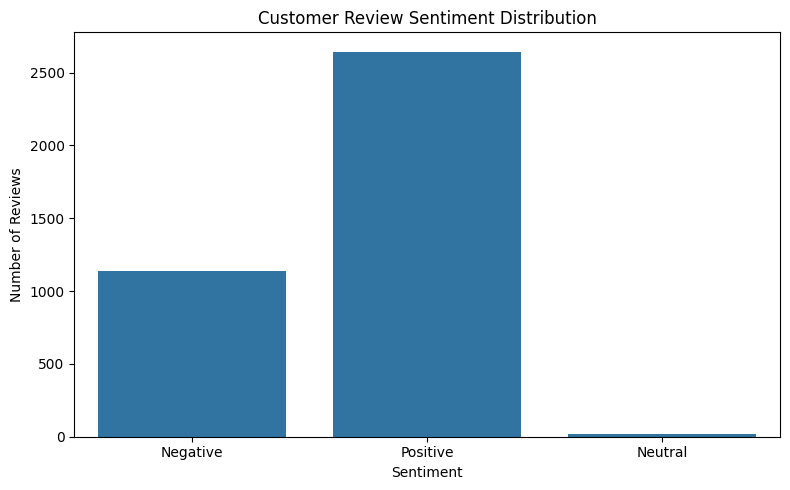

In [33]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Sentiment"
)

plt.title("Customer Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

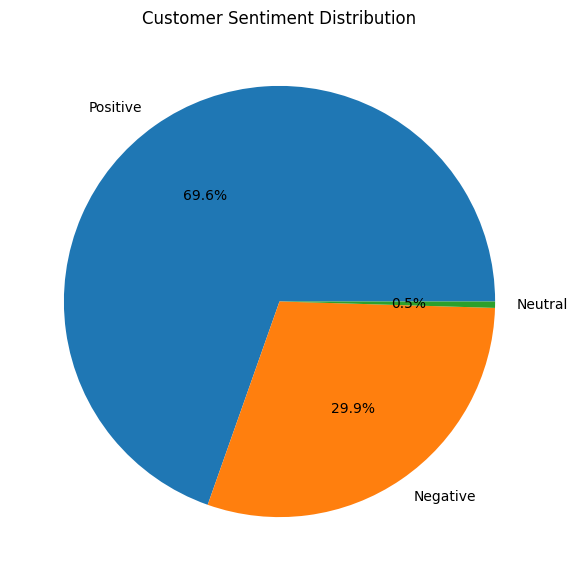

In [34]:
plt.figure(figsize=(7, 7))

sentiment_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Customer Sentiment Distribution")
plt.ylabel("")

plt.show()

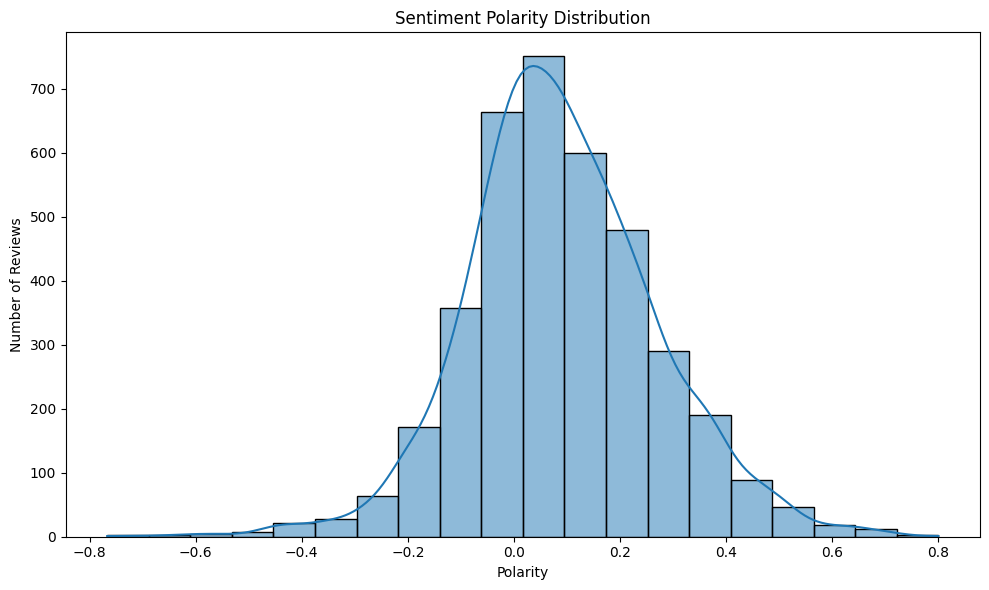

In [35]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data["Polarity"],
    bins=20,
    kde=True
)

plt.title("Sentiment Polarity Distribution")
plt.xlabel("Polarity")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

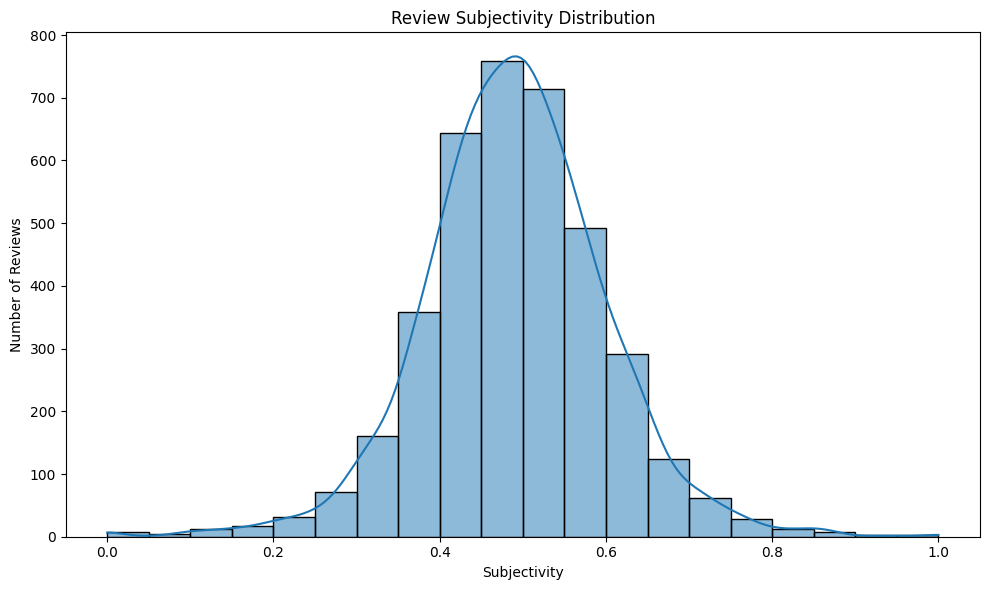

In [36]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data["Subjectivity"],
    bins=20,
    kde=True
)

plt.title("Review Subjectivity Distribution")
plt.xlabel("Subjectivity")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

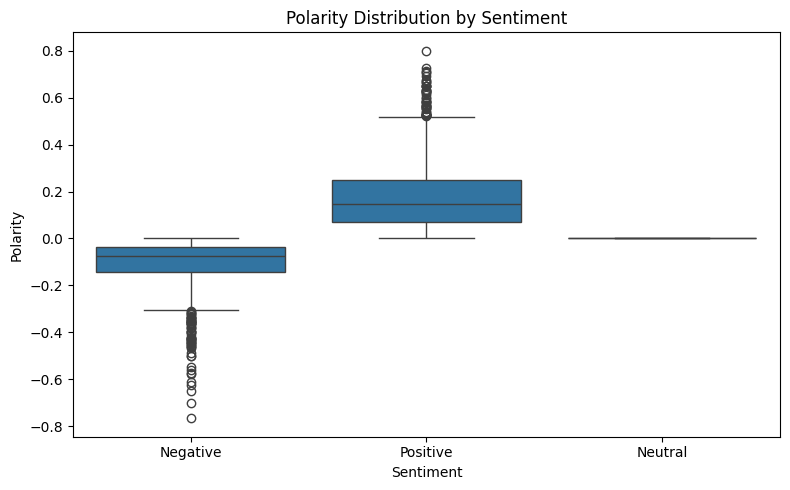

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="Sentiment",
    y="Polarity"
)

plt.title("Polarity Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Polarity")

plt.tight_layout()
plt.show()

In [38]:
most_positive = (
    data
    .sort_values(
        "Polarity",
        ascending=False
    )
    [["Review", "Polarity", "Sentiment"]]
    .head(10)
)

most_positive

,Review,Polarity,Sentiment
3452,Very impressed with Premium Economy on BA Sydn...,0.800000,Positive
3657,Flew BA 025 Heathrow to Hong Kong in First Cla...,0.725000,Positive
801,✅ Trip Verified | Gatwick to St Lucia. Great ...,0.715000,Positive
3512,BHD-LHR. I flew BA from Belfast George Best Ai...,0.709273,Positive
1293,✅ Trip Verified | Dubai to London Heathrow. L...,0.705000,Positive
41,✅ Trip Verified | I upgraded at check in to C...,0.694231,Positive
879,✅ Trip Verified | Edinburgh to Kuala Lumpur v...,0.673333,Positive
1462,✅ Trip Verified | Flew from London Heathrow to...,0.670000,Positive
778,✅ Trip Verified | Stockholm to London Heathro...,0.666667,Positive
3203,Heathrow - Mexico and Cancun - Gatwick in econ...,0.663333,Positive


In [39]:
most_negative = (
    data
    .sort_values(
        "Polarity",
        ascending=True
    )
    [["Review", "Polarity", "Sentiment"]]
    .head(10)
)

most_negative

,Review,Polarity,Sentiment
918,✅ Trip Verified | Mykonos to London flight de...,-0.766667,Negative
154,"Not Verified | The worst service ever, my bag...",-0.700000,Negative
926,✅ Trip Verified | Stockholm to London. Worst ...,-0.650000,Negative
1087,✅ Trip Verified | Miami to London. The breakf...,-0.622917,Negative
1099,✅ Trip Verified | San Francisco to London. Te...,-0.613333,Negative
3017,Terrible. Flight time is well over 2 hours. Se...,-0.579167,Negative
12,"✅ Trip Verified | Absolutely terrible, lost m...",-0.571429,Negative
527,Not Verified | The food was awful. An over ni...,-0.562500,Negative
1581,✅ Verified Review | I had a return flight to ...,-0.550000,Negative
2454,Singapore to London Heathrow with British Airw...,-0.500000,Negative


In [40]:
neutral_reviews = (
    data[
        data["Sentiment"] == "Neutral"
    ]
    [["Review", "Polarity", "Sentiment"]]
    .head(10)
)

neutral_reviews

,Review,Polarity,Sentiment
44,✅ Trip Verified | Communication and customer s...,0.0,Neutral
172,✅ Trip Verified | In June my flight was cance...,0.0,Neutral
204,Not Verified | BA is not treating its premium ...,0.0,Neutral
210,✅ Trip Verified | Came from Glasgow to London...,0.0,Neutral
383,✅ Trip Verified | Beyond disgusted with the fa...,0.0,Neutral
452,Not Verified | The flight was delayed over 6 ...,0.0,Neutral
542,✅ Trip Verified | For once more BA got it all...,0.0,Neutral
715,✅ Trip Verified | Johannesburg to Dublin via ...,0.0,Neutral
731,✅ Trip Verified | I purchased roundtrip ticket...,0.0,Neutral
864,✅ Trip Verified | Gatwick to Seville. When my...,0.0,Neutral


In [41]:
all_words = " ".join(
    data["Clean_Review"]
).split()

word_counts = Counter(all_words)

print(
    word_counts.most_common(20)
)

[('the', 30730), ('to', 20415), ('and', 18863), ('a', 14655), ('was', 13419), ('i', 11216), ('of', 8832), ('in', 8718), ('on', 8186), ('flight', 6814), ('for', 6520), ('with', 6083), ('not', 4924), ('ba', 4875), ('is', 4842), ('were', 4645), ('it', 4539), ('we', 4461), ('that', 4459), ('my', 4332)]


In [42]:
stop_words = {
    "the", "is", "a", "an", "and",
    "or", "to", "of", "in", "this",
    "that", "it", "for", "was",
    "with", "on", "i", "my",
    "very", "are", "but"
}

filtered_words = [
    word
    for word in all_words
    if word not in stop_words
]

In [43]:
word_counts = Counter(filtered_words)

common_words = pd.DataFrame(
    word_counts.most_common(10),
    columns=["Word", "Frequency"]
)

common_words

,Word,Frequency
0,flight,6814
1,not,4924
2,ba,4875
3,were,4645
4,we,4461
5,at,3998
6,they,3709
7,had,3676
8,as,3641
9,have,3460


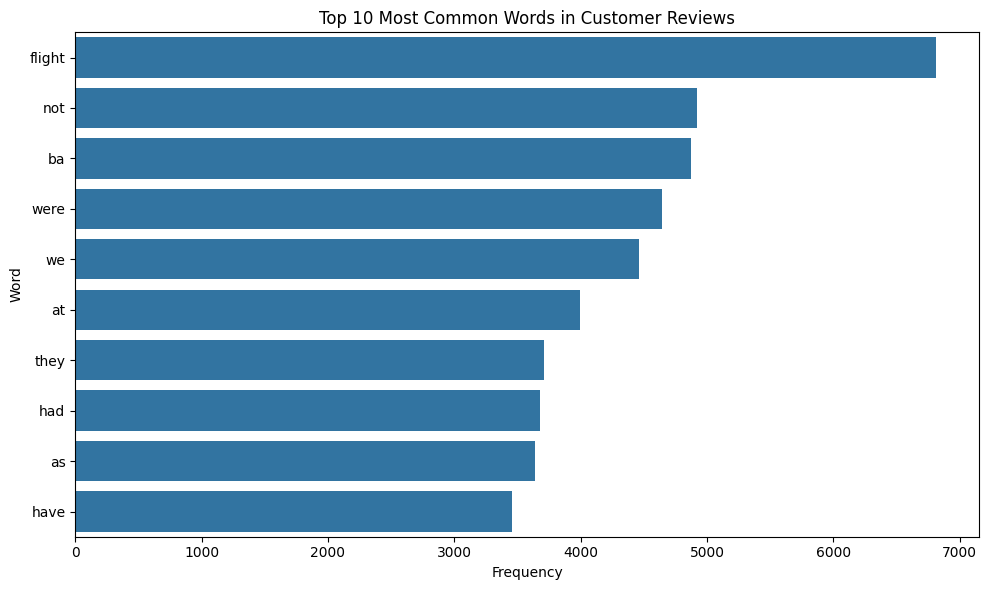

In [44]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=common_words,
    x="Frequency",
    y="Word"
)

plt.title("Top 10 Most Common Words in Customer Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

In [45]:
positive_count = (
    data["Sentiment"] == "Positive"
).sum()

negative_count = (
    data["Sentiment"] == "Negative"
).sum()

neutral_count = (
    data["Sentiment"] == "Neutral"
).sum()

print("Positive Reviews:", positive_count)
print("Negative Reviews:", negative_count)
print("Neutral Reviews:", neutral_count)

Positive Reviews: 2644
Negative Reviews: 1137
Neutral Reviews: 18


In [46]:
overall_sentiment = sentiment_counts.idxmax()

print(
    "Most common sentiment:",
    overall_sentiment
)

Most common sentiment: Positive


In [47]:
average_polarity = data["Polarity"].mean()

print(
    "Average Sentiment Polarity:",
    round(average_polarity, 3)
)

Average Sentiment Polarity: 0.089


In [50]:
print("FINAL SENTIMENT ANALYSIS RESULTS")

print("\nTotal Reviews:", len(data))

print("\nPositive Reviews:", positive_count)
print("Negative Reviews:", negative_count)
print("Neutral Reviews:", neutral_count)

print(
    "\nMost Common Sentiment:",
    overall_sentiment
)

print(
    "\nAverage Polarity:",
    round(average_polarity, 3)
)


FINAL SENTIMENT ANALYSIS RESULTS

Total Reviews: 3799

Positive Reviews: 2644
Negative Reviews: 1137
Neutral Reviews: 18

Most Common Sentiment: Positive

Average Polarity: 0.089


In [51]:
data.to_csv(
    "sentiment_analysis_results.csv",
    index=False
)

print(
    "Sentiment analysis results saved successfully!"
)

Sentiment analysis results saved successfully!


# Dataset Results

- Total reviews analyzed: 3799
- Positive reviews: 2644
- Negative reviews: 1137
- Neutral reviews: 18

- Average polarity: 0.089

# Key Business Insights
## Sentiment Findings
- The sentiment analysis classified customer reviews into Positive, Negative, and Neutral categories.
- The sentiment distribution shows the overall pattern of customer opinions in the dataset.
- Positive reviews can indicate areas where customers are satisfied.
- Negative reviews can help identify areas of customer dissatisfaction and potential improvement.
- Neutral reviews represent feedback with little or no detected positive or negative polarity.
- Sentiment polarity provides a numerical indication of the direction and strength of sentiment.
- Frequently occurring words help identify common topics discussed in customer reviews.

## Business Applications
The results of sentiment analysis can be used for:
1. Customer satisfaction monitoring
2. Product improvement
3. Marketing analysis
4. Customer feedback analysis
5. Identifying common complaints
6. Understanding customer opinions
7. Improving customer experience